## **Import Semua Library yang Diperlukan dan Baca Datasets**

**Import Keperluan**

In [5]:
import numpy as np        # operasi matematika
import pandas as pd       # baca & olah data (tabel)
import tensorflow as tf   # membuat model Compvis
import matplotlib.pyplot as plt  # membuat grafik
!pip install tensorflowjs
print("TensorFlow version:", tf.__version__)  # cek versi tensorflow

TensorFlow version: 2.19.0


**Import ZIP dan Ekstrak**

In [2]:
from google.colab import files
import zipfile
import os

# Upload file zip
uploaded = files.upload()

# Ekstrak zip
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Ekstrak selesai!")
print("\nStruktur folder:")
for root, dirs, files_list in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

Saving data.zip to data.zip
Ekstrak selesai!

Struktur folder:
dataset/
  data/
    test/
      Accident/
      Non Accident/
    val/
      Accident/
      Non Accident/
    train/
      Accident/
      Non Accident/


**Baca Datasets dari Folder Data kemudian Langsung Pisahkan untuk Train, Test dan Val**

In [1]:
from tensorflow.keras.preprocessing import image_dataset_from_directory as IMD

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH  = 224
SEED       = 42

train_ds = IMD(
    '/content/dataset/data/train',
    image_size=(IMG_HEIGHT, IMG_WIDTH),  # resize nya disini
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

val_ds = IMD(
    '/content/dataset/data/val',
    image_size=(IMG_HEIGHT, IMG_WIDTH), # resize nya disini
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,  # val tidak perlu diacak
    seed=SEED
)

test_ds = IMD(
    '/content/dataset/data/test', # resize nya disini
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,  # test tidak perlu diacak
    seed=SEED
)

print("Class names:", train_ds.class_names)
print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

Found 791 files belonging to 2 classes.
Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.
Class names: ['Accident', 'Non Accident']
Train batches : 25
Val batches   : 4
Test batches  : 4


**Lihat Contoh Gambar untuk Masing Masing Label per Datasets**

In [2]:
def show_one_per_class(dataset, dataset_name):
    class_names = dataset.class_names
    shown_labels = set()

    plt.figure(figsize=(8, 4))
    plot_idx = 1

    for images, labels in dataset:
        for i in range(len(images)):
            label = int(float(labels[i].numpy()[0]))
            if label not in shown_labels:
                plt.subplot(1, len(class_names), plot_idx)
                plt.imshow(images[i].numpy().astype("uint8"))
                plt.title(class_names[label])
                plt.axis("off")

                shown_labels.add(label)
                plot_idx += 1

            if len(shown_labels) == len(class_names):
                break

        if len(shown_labels) == len(class_names):
            break

    plt.suptitle(f"Contoh Gambar per Label - {dataset_name}")
    plt.tight_layout()
    plt.show()

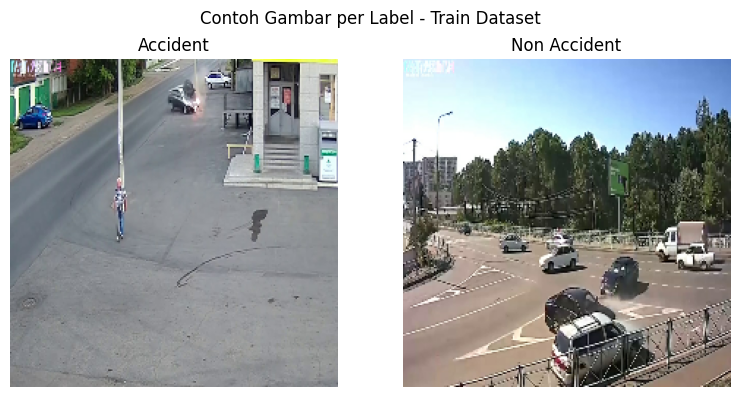

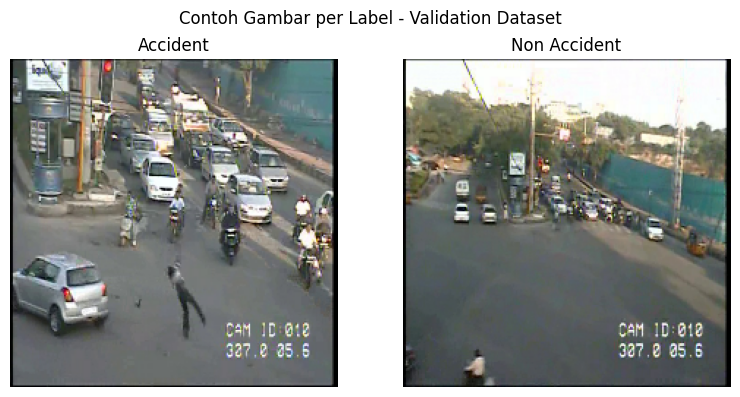

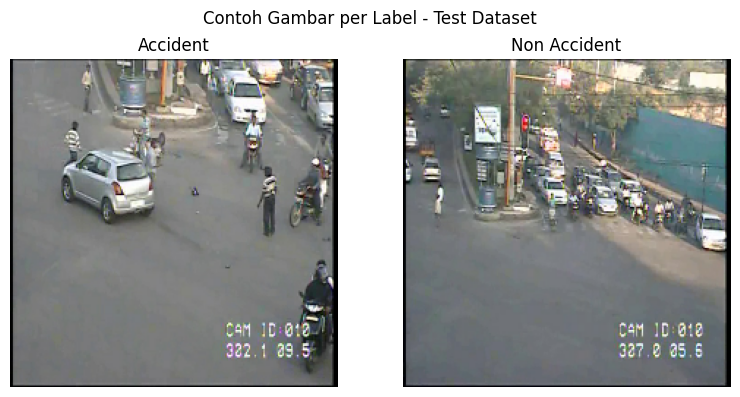

In [6]:
show_one_per_class(train_ds, "Train Dataset")
show_one_per_class(val_ds, "Validation Dataset")
show_one_per_class(test_ds, "Test Dataset")

In [3]:
for images, labels in train_ds.take(1):
    print(labels[0])
    print(labels[0].numpy())

tf.Tensor([0.], shape=(1,), dtype=float32)
[0.]


## **Prepocessing Datanya yang Sudah di Baca Tadi**

**Normalisasi Gambarnya**

In [6]:
nomralization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (nomralization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (nomralization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (nomralization_layer(x), y))

## **Model dan Juga Training**

**Buat Model CNN**

In [60]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

**Training Modelnya Menggunakan Datasets yang sudah di Proses Sebelumnya**

In [51]:
tf.random.set_seed(42)

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10,
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 225ms/step - accuracy: 0.5310 - loss: 0.9192 - val_accuracy: 0.5306 - val_loss: 0.6853
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - accuracy: 0.5689 - loss: 0.6780 - val_accuracy: 0.5918 - val_loss: 0.6527
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.6574 - loss: 0.6328 - val_accuracy: 0.6837 - val_loss: 0.6042
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.6776 - loss: 0.6229 - val_accuracy: 0.7449 - val_loss: 0.4922
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.7143 - loss: 0.5323 - val_accuracy: 0.8265 - val_loss: 0.3947
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.8028 - loss: 0.4405 - val_accuracy: 0.8061 - val_loss: 0.4228
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.8597 - loss: 0.3321 - val_accuracy: 0.8469 - val_loss: 0.2962
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.8761 - loss: 0.2878 - val_accuracy: 0.

**Grafik Validation untuk Melihat Hasil Model**

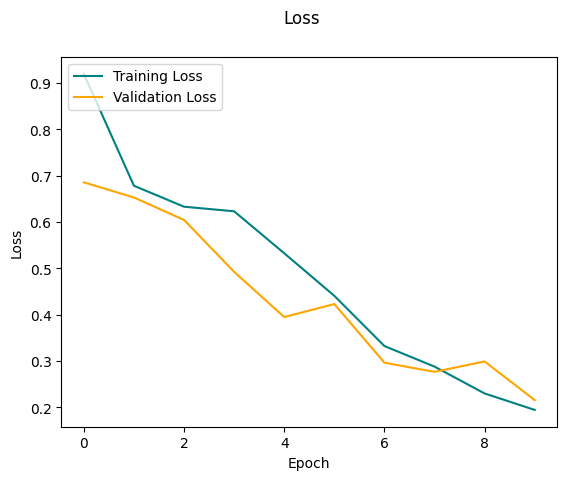

In [52]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='Training Loss')
plt.plot(history.history['val_loss'], color='orange', label='Validation Loss')
fig.suptitle('Loss')
plt.legend(loc="upper left")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

**Skor Model**

In [16]:
pip install scikit-learn

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9200
Precision : 0.9245
Recall    : 0.9245
F1 Score  : 0.9245


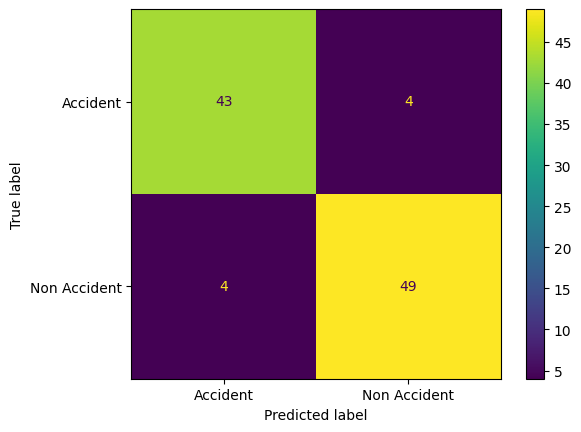

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Accident', 'Non Accident']
)

disp.plot()
plt.show()

**Testing Model menggunakan Datasets Test yang sudah Dipisah Sebelumnya**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


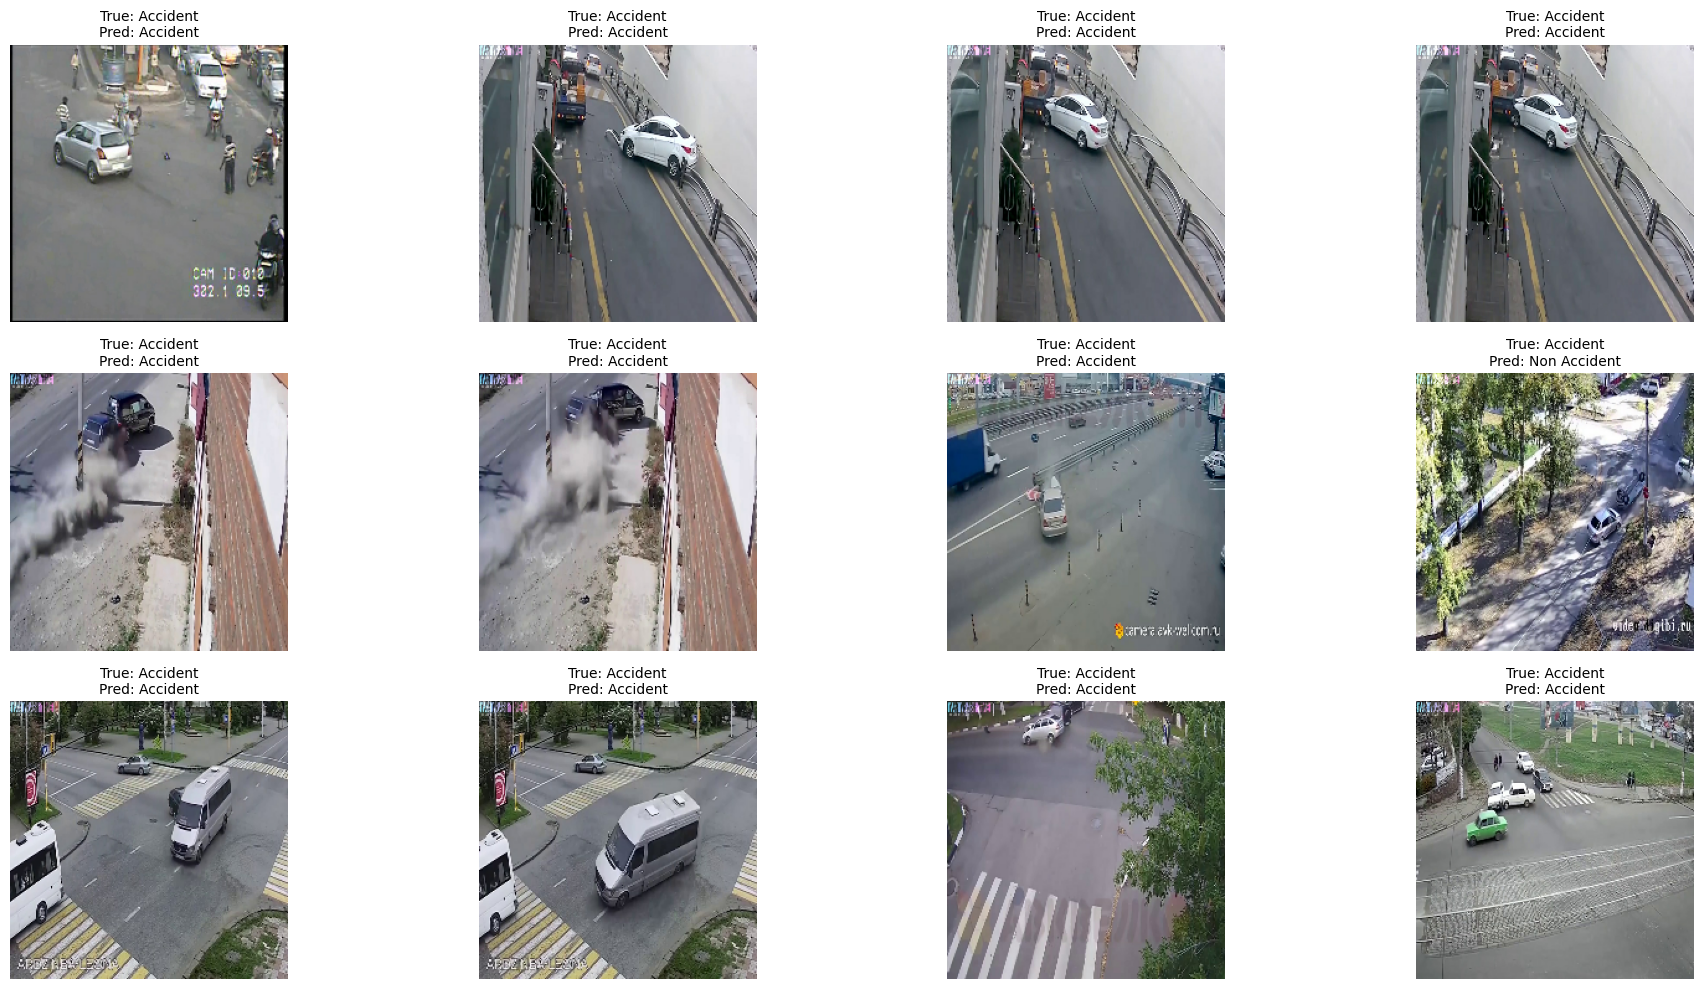

In [56]:
class_names = ['Accident', 'Non Accident']

for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    plt.figure(figsize=(20, 10))
    for i in range(min(len(images), 12)):
        ax = plt.subplot(3, 4, i + 1)
        img = (images[i].numpy() * 255).astype("uint8")
        plt.imshow(img)
        true_label = class_names[int(labels[i].numpy()[0])]
        pred_label = class_names[int(predictions[i][0] > 0.5)]
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            fontsize=10
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

**Konversi Menjadi JSON** **dan Export Menjadi Pickle**

In [66]:
import os
import shutil
from google.colab import files

model.save('accident_model_legacy.h5')
if os.path.exists('/content/tfjs_model'):
    shutil.rmtree('/content/tfjs_model')
    print("\n✓ Folder lama terdeteksi dan berhasil dibersihkan.")
os.makedirs('/content/tfjs_model', exist_ok=True)

!tensorflowjs_converter --input_format=keras accident_model_legacy.h5 /content/tfjs_model

shutil.make_archive('/content/tfjs_model', 'zip', '/content/tfjs_model')

files.download('/content/tfjs_model.zip')


✓ Folder lama terdeteksi dan berhasil dibersihkan.
2026-06-30 09:04:21.909550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782810261.935115   30145 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782810261.943278   30145 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782810261.964417   30145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782810261.964469   30145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782810261.964475   301

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
!pip show tensorflowjs

Name: tensorflowjs
Version: 4.22.0
Summary: 
Home-page: https://js.tensorflow.org/
Author: Google LLC
Author-email: opensource@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: flax, importlib_resources, jax, jaxlib, packaging, six, tensorflow, tensorflow-decision-forests, tensorflow-hub, tf-keras
Required-by: 


In [65]:
import os
print(sorted(os.listdir('/content/tfjs_model')))

['group1-shard10of22.bin', 'group1-shard11of22.bin', 'group1-shard12of22.bin', 'group1-shard13of22.bin', 'group1-shard14of22.bin', 'group1-shard15of22.bin', 'group1-shard16of22.bin', 'group1-shard17of22.bin', 'group1-shard18of22.bin', 'group1-shard19of22.bin', 'group1-shard1of22.bin', 'group1-shard20of22.bin', 'group1-shard21of22.bin', 'group1-shard22of22.bin', 'group1-shard2of22.bin', 'group1-shard3of22.bin', 'group1-shard4of22.bin', 'group1-shard5of22.bin', 'group1-shard6of22.bin', 'group1-shard7of22.bin', 'group1-shard8of22.bin', 'group1-shard9of22.bin', 'model.json']
